# Machine learning for NLP

Pada notebook ini adalah penerapan machine learning yang dilakukan untuk NLP. contoh penerapanya adalah text classification. pada colab ini dicoba penerapan supervised learning pada nlp menggunakan model Naive bayes dan Logistic regression (bisa dieksplor dengan model supervised lain). tahapan yang akan dilakukan sebagai berikut:

1.   Prepare train and test datasets
2.   Feature extraction and engineering (BoW dan TF-IDF)
3.   Model training
4.   Model prediction and evaluation
5.   Model deployment



## Import Library

In [ ]:
import pandas as pd
import numpy as np
import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

## Load Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

df = pd.read_csv(path + "/Womens Clothing E-Commerce Reviews.csv")

#feature selection
# Review text ->x
# Rating -> y
df = df[['Review Text', 'Rating']]
df = df.dropna()

df

Using Colab cache for faster access to the 'womens-ecommerce-clothing-reviews' dataset.


,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5
...,...,...
23481,I was very happy to snag this dress at such a ...,5
23482,"It reminds me of maternity clothes. soft, stre...",3
23483,"This fit well, but the top was very see throug...",3
23484,I bought this dress for a wedding i have this ...,3


**Import library spacy**

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

## Membuat Fungsi Cleaning

In [ ]:
def clean_text(texts):
    # lowercase
    texts = texts.str.lower()
    #Hapus karakter tidak penting
    texts = texts.str.replace(r'\[.*?\]', '', regex=True)
    texts = texts.str.replace(r'[^\w\s]', '', regex=True)

    # Tokenisasi + Lemmatization + hapus stopword + Hanya huruf (hapus angka)
    docs = nlp.pipe(texts, batch_size=500)
    cleaned = []
    for doc in docs:
        tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
        cleaned.append(' '.join(tokens))

    return cleaned

df['cleaned_text'] = clean_text(df['Review Text'])

In [ ]:
df.head()

,Review Text,Rating,cleaned_text
0,Absolutely wonderful - silky and sexy and comf...,4,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,5,love dress sooo pretty happen find store m gla...
2,I had such high hopes for this dress and reall...,3,high hope dress want work initially order peti...
3,"I love, love, love this jumpsuit. it's fun, fl...",5,love love love jumpsuit fun flirty fabulous ti...
4,This shirt is very flattering to all due to th...,5,shirt flattering adjustable tie perfect length...


In [ ]:
X = df['cleaned_text'] # fitur
y = df['Rating'] # label


Split data train dan test

porsi : 80 % data train dan 20 % data test

In [ ]:
# data train = 80%
# data test = 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))


Jumlah data training: 18112
Jumlah data testing: 4529


## Feature Extraction

CountVectorizer (BoW)

In [ ]:
count_vec = CountVectorizer(max_features=5000)

X_train_count = count_vec.fit_transform(X_train)
X_test_count = count_vec.transform(X_test)

x_train_df = pd.DataFrame(X_train_count.toarray(), columns=count_vec.get_feature_names_out())
x_train_df.head()

,aa,ab,abby,abdomen,ability,able,absolute,absolutely,abstract,absurd,...,zig,zigzag,zillion,zip,zipped,zipper,zippered,zips,zone,zoom
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


TF-IDF

In [ ]:
tfidf_vec = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

X_train_tfidf = pd.DataFrame(X_train_tfidf.toarray(), columns=count_vec.get_feature_names_out())
x_train_df.head()

,aa,ab,abby,abdomen,ability,able,absolute,absolutely,abstract,absurd,...,zig,zigzag,zillion,zip,zipped,zipper,zippered,zips,zone,zoom
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Training Model

Naive Bayes (Bow)

In [ ]:
nb_count = MultinomialNB()
nb_count.fit(X_train_count, y_train)

y_pred_nb_count = nb_count.predict(X_test_count)

print("Naive Bayes (CountVectorizer)")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_count))
print(classification_report(y_test, y_pred_nb_count))

Naive Bayes (CountVectorizer)
Accuracy: 0.6202252152793111
              precision    recall  f1-score   support

           1       0.35      0.19      0.25       148
           2       0.31      0.19      0.23       309
           3       0.38      0.39      0.39       588
           4       0.38      0.35      0.37       939
           5       0.77      0.85      0.81      2545

    accuracy                           0.62      4529
   macro avg       0.44      0.39      0.41      4529
weighted avg       0.60      0.62      0.61      4529



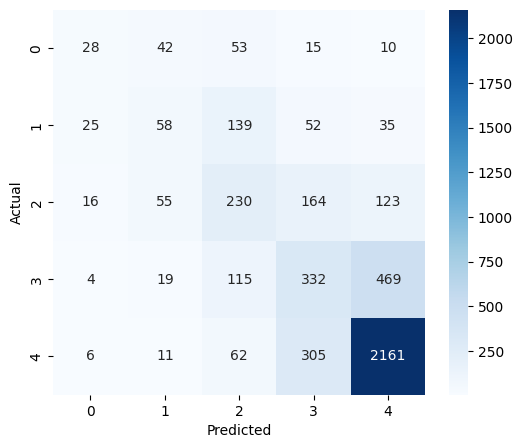

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb_count)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Naive Bayes (TF-IDF)

In [ ]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("Naive Bayes (TF-IDF)")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_tfidf))
print(classification_report(y_test, y_pred_nb_tfidf))

Naive Bayes (TF-IDF)
Accuracy: 0.5784941488187237
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       148
           2       0.00      0.00      0.00       309
           3       0.36      0.06      0.10       588
           4       0.29      0.05      0.09       939
           5       0.60      1.00      0.75      2545

    accuracy                           0.58      4529
   macro avg       0.25      0.22      0.19      4529
weighted avg       0.44      0.58      0.45      4529



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicte

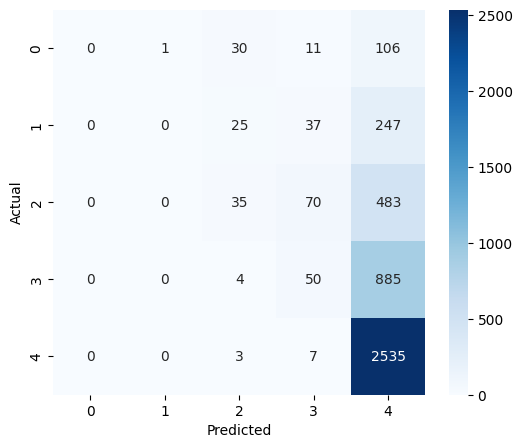

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb_tfidf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression (TF-IDF)

In [ ]:
lr_bow = LogisticRegression(max_iter=1000)

lr_bow.fit(X_train_count, y_train)

y_pred_lr_bow = lr_bow.predict(X_train_count)

print("Logistic Regression (CountVectorizer)")
print("Accuracy:", accuracy_score(y_test, y_pred_nb_count))
print(classification_report(y_test, y_pred_nb_count))

Logistic Regression (CountVectorizer)
Accuracy: 0.6202252152793111
              precision    recall  f1-score   support

           1       0.35      0.19      0.25       148
           2       0.31      0.19      0.23       309
           3       0.38      0.39      0.39       588
           4       0.38      0.35      0.37       939
           5       0.77      0.85      0.81      2545

    accuracy                           0.62      4529
   macro avg       0.44      0.39      0.41      4529
weighted avg       0.60      0.62      0.61      4529



In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression (TF-IDF)")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression (TF-IDF)
Accuracy: 0.6350187679399426
              precision    recall  f1-score   support

           1       0.40      0.13      0.19       148
           2       0.37      0.19      0.25       309
           3       0.41      0.32      0.36       588
           4       0.40      0.28      0.33       939
           5       0.73      0.92      0.82      2545

    accuracy                           0.64      4529
   macro avg       0.46      0.37      0.39      4529
weighted avg       0.59      0.64      0.60      4529



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


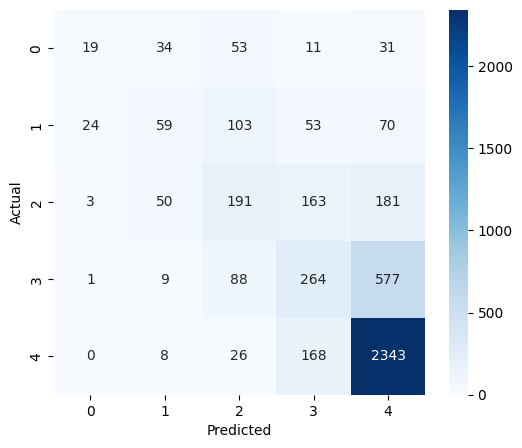

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Comparative models

In [ ]:
def evaluate_model(name, y_test, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (weighted)": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision'],
        "Recall (weighted)": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall'],
        "F1-score (weighted)": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    }

In [ ]:
results = []

# NB Count
results.append(
    evaluate_model("NB + Count", y_test, y_pred_nb_count)
)

# NB TF-IDF
results.append(
    evaluate_model("NB + TF-IDF", y_test, y_pred_nb_tfidf)
)

# Logistic Regression
results.append(
    evaluate_model("LogReg + TF-IDF", y_test, y_pred_lr)
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
results_df = pd.DataFrame(results)
print(results_df)

             Model  Accuracy  Precision (weighted)  Recall (weighted)  \
0       NB + Count  0.620225              0.596128           0.620225   
1      NB + TF-IDF  0.578494              0.440788           0.578494   
2  LogReg + TF-IDF  0.635019              0.586402           0.635019   

   F1-score (weighted)  
0             0.605135  
1             0.450789  
2             0.597508  


In [ ]:
import numpy as np

reviews_test_data = df.loc[X_test.index].copy()

reviews_test_data['predictions_nb_class1'] = nb_count.predict_proba(X_test_count)[:, 0]
reviews_test_data['predictions_nb_class2'] = nb_tfidf.predict_proba(X_test_tfidf)[:, 0]
reviews_test_data['predictions_lr_class1'] = lr.predict_proba(X_test_tfidf)[:, 0]

reviews_test_data.sort_values('predictions_nb_class1', ascending=False).head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,Review Text,Rating,cleaned_text,predictions_nb_class1,predictions_nb_class2,predictions_lr_class1
12942,Luckily i bought this on sale... i now see the...,1,luckily buy sale instruction online hand wash ...,0.999707,0.128772,0.249563
3587,"These pants looked worn, washed & old looking ...",2,pant look worn wash old looking receive qualit...,0.998537,0.113992,0.771060
8772,I purchased these pants on 12/2/15 as a more f...,1,purchase pant fashionable alternative yoga pan...,0.996112,0.084467,0.122684
5153,This was my absolute favorite top before it tr...,3,absolute favorite transfer dye driver seat car...,0.995967,0.168998,0.126068
13947,"This is one of those ""why we shop at retailer ...",5,shop retailer dress dress arrive today lasersh...,0.995194,0.146753,0.164178


**Inference Manual**

In [ ]:
import re

def clean_text_single(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

    return ' '.join(tokens)


def predict_review(text):
    cleaned = clean_text_single(text)
    vectorized = tfidf_vec.transform([cleaned])
    pred = lr.predict(vectorized)[0]

    return {str(pred): 1.0}   # untuk gr.Label

In [ ]:
sample_text = ["i love this dress"]

cleaned = [clean_text_single(text) for text in sample_text]

vectorized = tfidf_vec.transform(cleaned)

prediction = lr.predict(vectorized)

print("Text:", sample_text[0])
print("Predicted Rating:", prediction[0])

Text: i love this dress
Predicted Rating: 5


Inference dengan interface Gradio

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

iface = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(
        label="Customer Review",
        lines=3,
        placeholder="Type review here..."
    ),
    outputs=gr.Label(num_top_classes=1),
    title="🛍️ Clothing Review Analyzer",
    description="Predict rating (1–5) from customer review using NLP",
    examples=[
        ["I love this dress, very beautiful"],
        ["Terrible quality, I returned it"],
        ["It's okay, nothing special"]
    ]
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://adffbfc1b3f7dab35a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
feature_names = tfidf_vec.get_feature_names_out()

for i, class_label in enumerate(lr.classes_):
    top10 = np.argsort(lr.coef_[i])[-10:]
    print(f"Top words for rating {class_label}:")
    print([feature_names[j] for j in top10])

Top words for rating 1:
['completely', 'unflattering', 'tent', 'disappointment', 'awful', 'poor', 'bad', 'disappointed', 'terrible', 'cheap']
Top words for rating 2:
['bad', 'bummer', 'go', 'awkward', 'want', 'unfortunately', 'huge', 'unflattering', 'return', 'disappointed']
Top words for rating 3:
['continue', 'sad', 'frame', 'pille', 'potential', 'unfortunately', 'average', 'excited', 'ok', 'return']
Top words for rating 4:
['issue', 'lovely', 'casual', 'hopefully', 'comfortable', 'great', 'star', 'complaint', 'bit', 'little']
Top words for rating 5:
['justice', 'soft', 'great', 'glad', 'comfortable', 'compliment', 'highly', 'perfectly', 'love', 'perfect']


In [ ]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['Rating'].apply(rating_to_sentiment)

In [ ]:
df[['Review Text', 'Rating', 'sentiment']].head()

,Review Text,Rating,sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,positive
1,Love this dress! it's sooo pretty. i happene...,5,positive
2,I had such high hopes for this dress and reall...,3,neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",5,positive
4,This shirt is very flattering to all due to th...,5,positive
